# 🤖 Pipeline d'analyse — Missions d'inspection Pathfinder
## Acwa Robotics | Data Analyst Project

---

**Contexte :**  
Acwa Robotics développe le robot **Pathfinder**, qui circule à l'intérieur des canalisations d'eau pour en inspecter l'état structural. Le robot collecte, à intervalle régulier, des mesures issues de plusieurs capteurs embarqués.

**Objectif de ce notebook :**  
Simuler le workflow complet d'un Data Analyst traitant les données brutes d'une mission d'inspection — de la validation des données jusqu'à la production d'un rapport exportable.

---

### Workflow

| Étape | Description |
|-------|-------------|
| **0** | Configuration & imports |
| **1** | Chargement & validation des données |
| **2** | Exploration des données (EDA) |
| **3** | Détection d'anomalies |
| **4** | Classification de la gravité |
| **5** | Visualisations |
| **6** | Export du rapport |

---

**Stack :** Python · Pandas · NumPy · Matplotlib  
**Mission simulée :** MSN-2024-DKK-007 · Dunkerque, réseau Nord · 14 octobre 2024


---
## ⚙️ Étape 0 — Configuration & imports

On commence par importer les librairies nécessaires et définir tous les paramètres
métier en un seul endroit. Centraliser la configuration ici permet de faire varier
les seuils sans toucher au reste du code.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

# ── Style global des graphiques ───────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linestyle":     "--",
    "figure.facecolor":   "white",
    "axes.facecolor":     "#FAFBFC",
})

# ── Paramètres métier ─────────────────────────────────────────────────────────
MISSION_ID        = "MSN-2024-DKK-007"
RESEAU            = "Dunkerque — Zone Nord"
OPERATEUR         = "SUEZ / Agence de l'eau Artois-Picardie"
NOMINAL_THICKNESS = 8.5    # mm — épaisseur nominale des canalisations acier DN200

# Paramètre de détection d'anomalies
Z_SCORE_THRESHOLD = 2.0    # seuil de z-score sur l'épaisseur

# Seuils de classification gravité (% perte d'épaisseur vs nominal)
SEUIL_FAIBLE    =  5   # %
SEUIL_MODERE    = 15   # %
SEUIL_CRITIQUE  = 30   # %

# Chemins
DATA_PATH   = Path("../data/mission_sample.csv")
OUTPUT_DIR  = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Palette couleurs
COLORS = {
    "ok":        "#2ECC71",
    "faible":    "#F39C12",
    "modere":    "#E67E22",
    "critique":  "#E74C3C",
    "blue":      "#1A3557",
    "lightblue": "#D6E4F0",
    "gray":      "#7F8C8D",
}

SEV_COLOR_MAP = {
    "OK":       COLORS["ok"],
    "FAIBLE":   COLORS["faible"],
    "MODÉRÉ":   COLORS["modere"],
    "CRITIQUE": COLORS["critique"],
}

print("✔ Configuration chargée")
print(f"  Mission       : {MISSION_ID}")
print(f"  Réseau        : {RESEAU}")
print(f"  Épaisseur nom.: {NOMINAL_THICKNESS} mm")
print(f"  Seuil z-score : {Z_SCORE_THRESHOLD}")
print(f"  Seuils gravité: FAIBLE={SEUIL_FAIBLE}% | MODÉRÉ={SEUIL_MODERE}% | CRITIQUE={SEUIL_CRITIQUE}%")


✔ Configuration chargée
  Mission       : MSN-2024-DKK-007
  Réseau        : Dunkerque — Zone Nord
  Épaisseur nom.: 8.5 mm
  Seuil z-score : 2.0
  Seuils gravité: FAIBLE=5% | MODÉRÉ=15% | CRITIQUE=30%


---
## 📥 Étape 1 — Chargement & validation des données

Avant toute analyse, on valide systématiquement les données brutes :
- **Typage** : les colonnes ont-elles le bon type ?
- **Complétude** : y a-t-il des valeurs manquantes ?
- **Cohérence physique** : les valeurs sont-elles dans des plages réalistes pour les capteurs ?

Cette étape est cruciale sur des données industrielles où des pannes capteurs ou
des artefacts de transmission peuvent produire des valeurs aberrantes.


In [2]:
# ── Chargement ────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

print(f"✔ Fichier chargé : {DATA_PATH}")
print(f"  {len(df)} lignes × {len(df.columns)} colonnes")
print()

# ── Aperçu des premières lignes ───────────────────────────────────────────────
df.head(8)


✔ Fichier chargé : ../data/mission_sample.csv
  120 lignes × 12 colonnes



,timestamp,position_m,x_gps,y_gps,epaisseur_mm,corrosion_pct,signal_us_db,confiance_pct,temp_eau_c,pression_bar,vitesse_cmps,frame_id
0,2024-10-14 08:30:00,0.0,2.589414,51.034568,8.55,0.0,75.5,99.0,12.5,3.27,4.8,FRM-0001
1,2024-10-14 08:30:08,4.1,2.589428,51.034573,8.34,3.2,74.0,97.6,12.2,3.15,5.2,FRM-0002
2,2024-10-14 08:30:16,8.2,2.589448,51.034586,8.61,0.0,75.0,95.2,12.5,3.08,5.2,FRM-0003
3,2024-10-14 08:30:24,12.3,2.589466,51.034594,8.64,0.0,73.9,93.4,11.9,3.28,4.9,FRM-0004
4,2024-10-14 08:30:32,16.4,2.589486,51.034603,8.21,2.2,74.7,97.4,12.3,3.33,5.3,FRM-0005
5,2024-10-14 08:30:40,20.5,2.589505,51.034615,8.30,0.3,74.7,97.0,12.4,3.18,5.0,FRM-0006
6,2024-10-14 08:30:48,24.6,2.589521,51.034625,8.52,0.0,78.1,98.9,12.4,3.10,5.1,FRM-0007
7,2024-10-14 08:30:56,28.6,2.589543,51.034635,8.45,0.5,77.2,99.0,12.6,3.18,5.3,FRM-0008


In [3]:
# ── Types et structure du DataFrame ──────────────────────────────────────────
print("Structure du DataFrame :")
print("-" * 45)
df.info()


Structure du DataFrame :
---------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      120 non-null    datetime64[us]
 1   position_m     120 non-null    float64       
 2   x_gps          120 non-null    float64       
 3   y_gps          120 non-null    float64       
 4   epaisseur_mm   120 non-null    float64       
 5   corrosion_pct  120 non-null    float64       
 6   signal_us_db   120 non-null    float64       
 7   confiance_pct  120 non-null    float64       
 8   temp_eau_c     120 non-null    float64       
 9   pression_bar   120 non-null    float64       
 10  vitesse_cmps   120 non-null    float64       
 11  frame_id       120 non-null    str           
dtypes: datetime64[us](1), float64(10), str(1)
memory usage: 11.4 KB


In [4]:
# ── Vérification 1 : valeurs manquantes ──────────────────────────────────────
missing = df.isnull().sum()
n_missing = missing.sum()

if n_missing == 0:
    print("✔ Aucune valeur manquante détectée")
else:
    print(f"⚠ {n_missing} valeur(s) manquante(s) :")
    print(missing[missing > 0])


✔ Aucune valeur manquante détectée


In [5]:
# ── Vérification 2 : plages physiques cohérentes ─────────────────────────────
# Ces plages sont définies par les spécifications techniques des capteurs
plages_physiques = {
    "epaisseur_mm":  (3.0,  12.0),   # mm — canalisation DN200 acier
    "corrosion_pct": (0.0, 100.0),   # % — perte d'épaisseur
    "signal_us_db":  (40.0, 85.0),  # dB — amplitude signal ultrason
    "confiance_pct": (0.0, 100.0),  # % — score de fiabilité mesure
    "pression_bar":  (0.5,   8.0),  # bar — pression réseau eau potable
    "temp_eau_c":    (2.0,  30.0),  # °C — température de l'eau
}

print("Vérification des plages physiques :")
print("-" * 50)
for col, (lo, hi) in plages_physiques.items():
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    status = "✔" if n_out == 0 else f"⚠ {n_out} valeur(s) hors plage"
    print(f"  {col:<20} [{lo:>5} – {hi:>5}]   {status}")


Vérification des plages physiques :
--------------------------------------------------
  epaisseur_mm         [  3.0 –  12.0]   ✔
  corrosion_pct        [  0.0 – 100.0]   ✔
  signal_us_db         [ 40.0 –  85.0]   ✔
  confiance_pct        [  0.0 – 100.0]   ✔
  pression_bar         [  0.5 –   8.0]   ✔
  temp_eau_c           [  2.0 –  30.0]   ✔


In [6]:
# ── Calcul des variables dérivées ────────────────────────────────────────────
# Ces deux colonnes seront utiles pour la détection et la classification

# Écart à l'épaisseur nominale (positif = trop épais, négatif = trop mince)
df["delta_epaisseur_mm"] = np.round(df["epaisseur_mm"] - NOMINAL_THICKNESS, 2)

# Perte d'épaisseur relative (%) — c'est le KPI principal pour la gravité
df["perte_pct"] = np.round(
    (NOMINAL_THICKNESS - df["epaisseur_mm"]) / NOMINAL_THICKNESS * 100, 1
)

print("✔ Variables dérivées ajoutées :")
print("   delta_epaisseur_mm = epaisseur_mm - NOMINAL_THICKNESS")
print("   perte_pct          = (NOMINAL - epaisseur) / NOMINAL × 100")
print()
print(df[["position_m", "epaisseur_mm", "delta_epaisseur_mm", "perte_pct"]].head(10).to_string(index=False))


✔ Variables dérivées ajoutées :
   delta_epaisseur_mm = epaisseur_mm - NOMINAL_THICKNESS
   perte_pct          = (NOMINAL - epaisseur) / NOMINAL × 100

 position_m  epaisseur_mm  delta_epaisseur_mm  perte_pct
        0.0          8.55                0.05       -0.6
        4.1          8.34               -0.16        1.9
        8.2          8.61                0.11       -1.3
       12.3          8.64                0.14       -1.6
       16.4          8.21               -0.29        3.4
       20.5          8.30               -0.20        2.4
       24.6          8.52                0.02       -0.2
       28.6          8.45               -0.05        0.6
       32.7          8.50                0.00        0.0
       36.8          8.37               -0.13        1.5


---
## 🔍 Étape 2 — Exploration des données (EDA)

L'EDA (Exploratory Data Analysis) permet de comprendre la distribution des variables,
d'identifier des corrélations et de poser les bases pour la détection d'anomalies.

On s'intéresse principalement à :
- Les **statistiques descriptives** des variables capteurs
- La **distribution de l'épaisseur** (variable cible principale)
- Les **corrélations** entre variables physiques


In [7]:
# ── Statistiques descriptives des variables capteurs ─────────────────────────
capteur_cols = [
    "epaisseur_mm", "corrosion_pct", "signal_us_db",
    "confiance_pct", "pression_bar", "temp_eau_c"
]

stats = df[capteur_cols].describe().round(2)
print("Statistiques descriptives :")
stats


Statistiques descriptives :


,epaisseur_mm,corrosion_pct,signal_us_db,confiance_pct,pression_bar,temp_eau_c
count,120.00,120.00,120.00,120.00,120.00,120.00
mean,8.06,5.66,73.15,95.93,3.19,12.37
std,0.94,10.87,4.07,3.67,0.05,0.28
min,5.01,0.00,58.60,83.00,3.07,11.70
25%,8.25,0.00,72.68,95.15,3.15,12.20
50%,8.45,0.70,74.40,97.30,3.19,12.40
75%,8.56,3.38,75.60,98.72,3.23,12.60
max,8.74,40.00,78.50,99.00,3.33,13.00


In [8]:
# ── Résumé mission ────────────────────────────────────────────────────────────
duree = df["timestamp"].max() - df["timestamp"].min()
print("=" * 50)
print(f"  RÉSUMÉ MISSION {MISSION_ID}")
print("=" * 50)
print(f"  Points de mesure     : {len(df)}")
print(f"  Longueur inspectée   : {df['position_m'].max():.0f} m")
print(f"  Durée de mission     : {duree}")
print(f"  Épaisseur moyenne    : {df['epaisseur_mm'].mean():.2f} mm (nominal: {NOMINAL_THICKNESS} mm)")
print(f"  Épaisseur min / max  : {df['epaisseur_mm'].min():.2f} / {df['epaisseur_mm'].max():.2f} mm")
print(f"  Corrosion max        : {df['corrosion_pct'].max():.1f} %")
print(f"  Confiance moy.       : {df['confiance_pct'].mean():.1f} %")


  RÉSUMÉ MISSION MSN-2024-DKK-007
  Points de mesure     : 120
  Longueur inspectée   : 487 m
  Durée de mission     : 0 days 00:15:52
  Épaisseur moyenne    : 8.06 mm (nominal: 8.5 mm)
  Épaisseur min / max  : 5.01 / 8.74 mm
  Corrosion max        : 40.0 %
  Confiance moy.       : 95.9 %


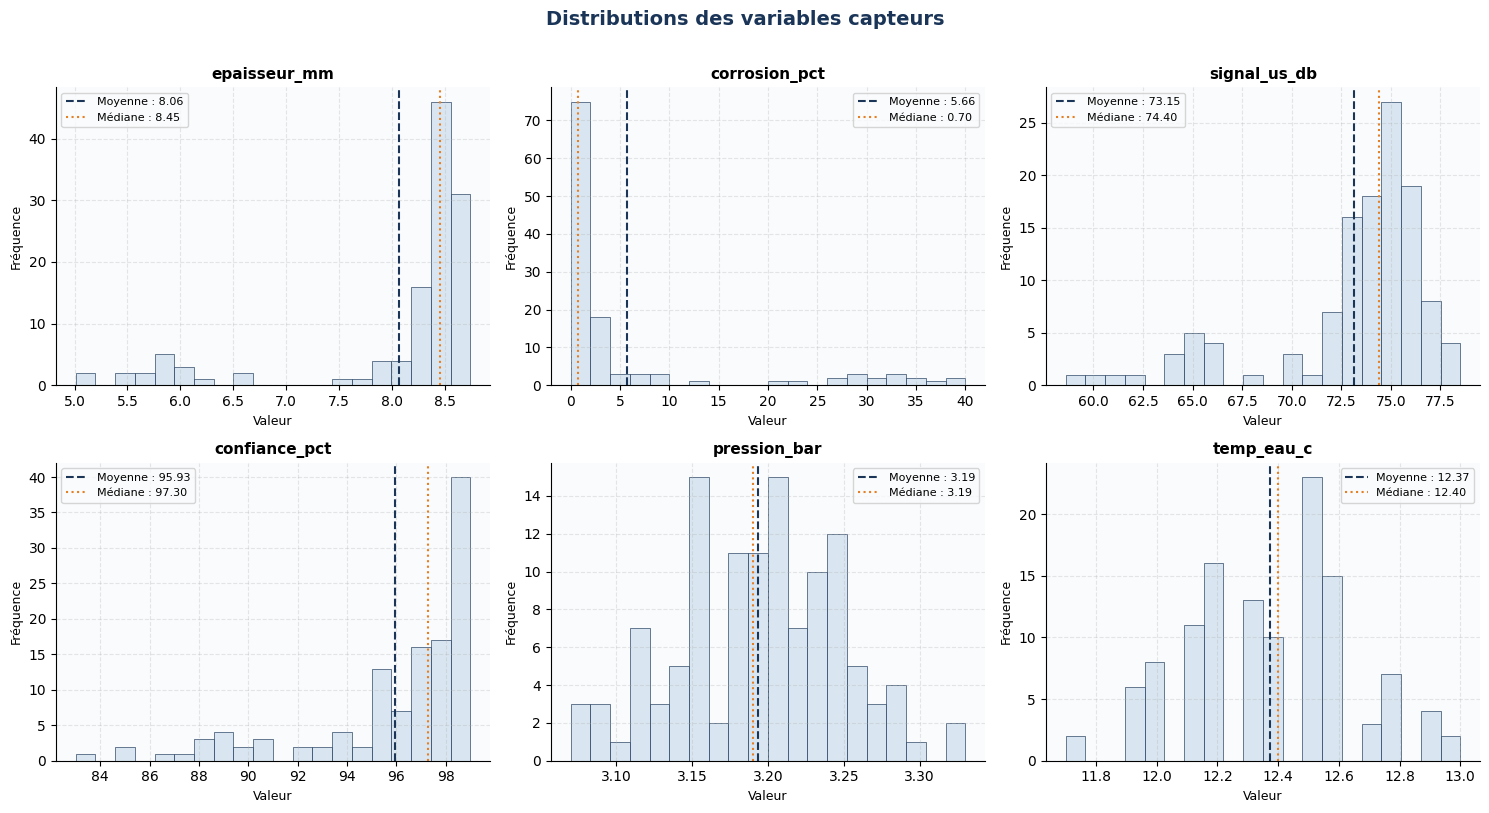

✔ Figure sauvegardée → outputs/eda_distributions.png


In [9]:
# ── Distributions des variables principales ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distributions des variables capteurs", fontsize=14,
             fontweight="bold", color=COLORS["blue"], y=1.01)

for ax, col in zip(axes.flat, capteur_cols):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    ax.hist(df[col], bins=20, color=COLORS["lightblue"],
            edgecolor=COLORS["blue"], linewidth=0.5, alpha=0.9)
    ax.axvline(df[col].mean(), color=COLORS["blue"], linestyle="--",
               linewidth=1.5, label=f"Moyenne : {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color=COLORS["modere"], linestyle=":",
               linewidth=1.5, label=f"Médiane : {df[col].median():.2f}")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("Valeur", fontsize=9)
    ax.set_ylabel("Fréquence", fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Figure sauvegardée → outputs/eda_distributions.png")


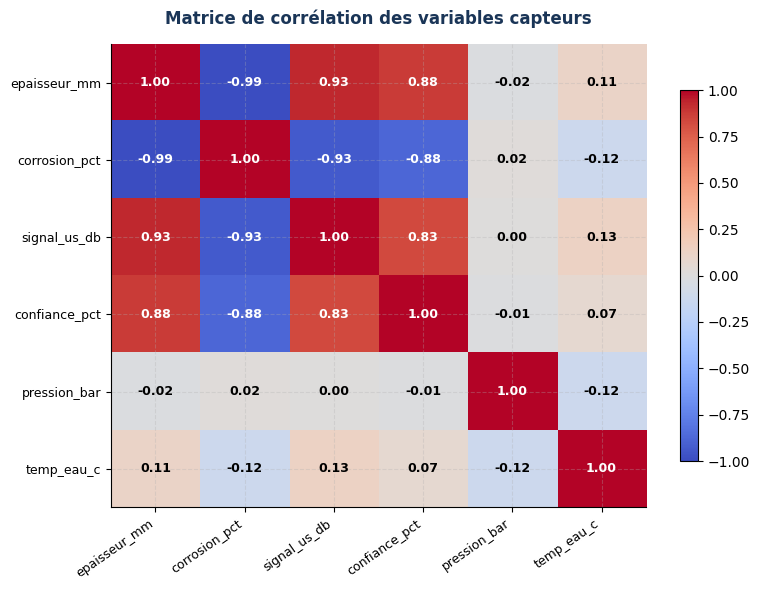

✔ Figure sauvegardée → outputs/eda_correlation.png


In [10]:
# ── Matrice de corrélation ─────────────────────────────────────────────────────
# On vérifie les corrélations physiques attendues :
#   - épaisseur ↓  ↔  corrosion ↑  (corrélation négative forte attendue)
#   - corrosion ↑  ↔  signal_us ↓  (un signal plus faible = paroi dégradée)
#   - corrosion ↑  ↔  confiance ↓  (mesure moins fiable sur zones dégradées)

corr_matrix = df[capteur_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(capteur_cols)))
ax.set_yticks(range(len(capteur_cols)))
ax.set_xticklabels(capteur_cols, rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(capteur_cols, fontsize=9)
ax.set_title("Matrice de corrélation des variables capteurs",
             fontsize=12, fontweight="bold", color=COLORS["blue"], pad=14)

# Annoter chaque cellule avec la valeur
for i in range(len(capteur_cols)):
    for j in range(len(capteur_cols)):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=9, fontweight="bold", color=color)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Figure sauvegardée → outputs/eda_correlation.png")


---
## 🚨 Étape 3 — Détection d'anomalies

On combine deux approches complémentaires pour détecter les anomalies :

### Méthode 1 : Z-score statistique
Le z-score mesure l'écart d'une mesure à la moyenne en unités d'écart-type.
Un z-score inférieur à **-2.0** signifie que l'épaisseur est anormalement basse
(dans le 2.5% inférieur de la distribution).

$$z = \frac{x - \mu}{\sigma}$$

### Méthode 2 : Seuils métier
Indépendamment de la distribution statistique, on applique des seuils basés
sur les **spécifications techniques des canalisations** : toute perte d'épaisseur
supérieure à 5% est considérée comme une anomalie à surveiller.

Les deux méthodes sont combinées en **union logique** : un point est une anomalie
si *au moins une* des deux conditions est vraie.


In [11]:
# ── Calcul du z-score sur l'épaisseur ─────────────────────────────────────────
mean_thick = df["epaisseur_mm"].mean()
std_thick  = df["epaisseur_mm"].std()

df["z_score_epaisseur"] = np.round(
    (df["epaisseur_mm"] - mean_thick) / std_thick, 2
)

print(f"Épaisseur — moyenne : {mean_thick:.3f} mm | écart-type : {std_thick:.3f} mm")
print(f"Seuil z-score appliqué : < -{Z_SCORE_THRESHOLD}")
print()

# Points hors seuil
n_zscore = (df["z_score_epaisseur"] < -Z_SCORE_THRESHOLD).sum()
print(f"Points avec z-score < -{Z_SCORE_THRESHOLD} : {n_zscore}")


Épaisseur — moyenne : 8.065 mm | écart-type : 0.943 mm
Seuil z-score appliqué : < -2.0

Points avec z-score < -2.0 : 14


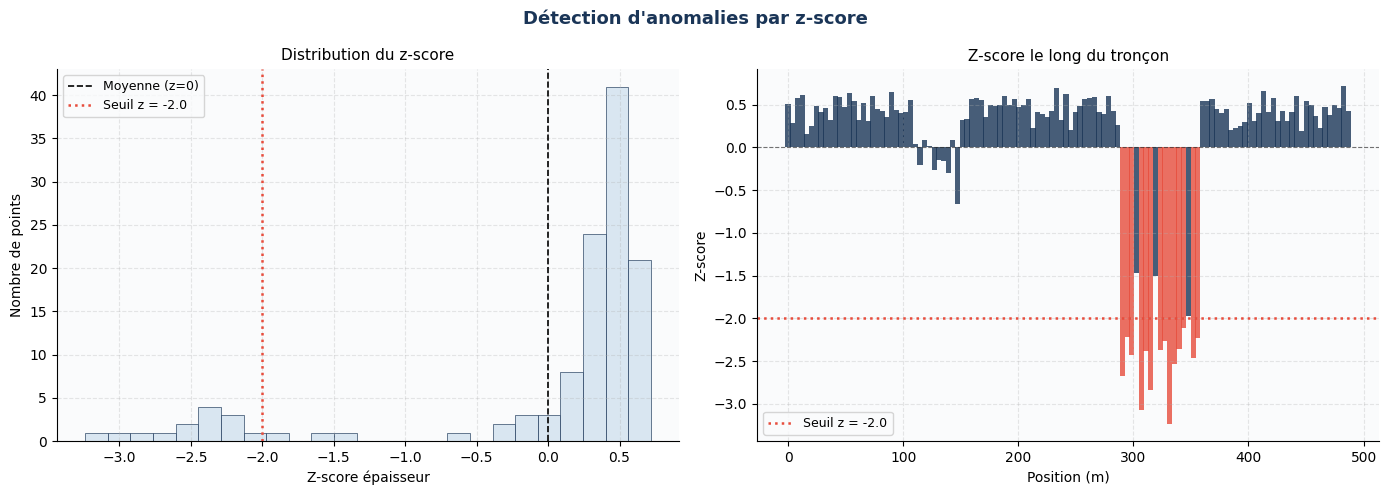

✔ Figure sauvegardée → outputs/detection_zscore.png


In [12]:
# ── Visualisation du z-score ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Détection d'anomalies par z-score", fontsize=13,
             fontweight="bold", color=COLORS["blue"])

# Distribution du z-score
ax = axes[0]
ax.hist(df["z_score_epaisseur"], bins=25, color=COLORS["lightblue"],
        edgecolor=COLORS["blue"], linewidth=0.5, alpha=0.9)
ax.axvline(0,                  color="black",          linestyle="--", linewidth=1.2, label="Moyenne (z=0)")
ax.axvline(-Z_SCORE_THRESHOLD, color=COLORS["critique"], linestyle=":",  linewidth=1.8, label=f"Seuil z = -{Z_SCORE_THRESHOLD}")
ax.set_xlabel("Z-score épaisseur", fontsize=10)
ax.set_ylabel("Nombre de points", fontsize=10)
ax.set_title("Distribution du z-score", fontsize=11)
ax.legend(fontsize=9)

# Z-score le long du tronçon
ax2 = axes[1]
colors_z = [COLORS["critique"] if z < -Z_SCORE_THRESHOLD else COLORS["blue"]
            for z in df["z_score_epaisseur"]]
ax2.bar(df["position_m"], df["z_score_epaisseur"],
        color=colors_z, width=4.5, alpha=0.8)
ax2.axhline(-Z_SCORE_THRESHOLD, color=COLORS["critique"], linestyle=":",
            linewidth=1.8, label=f"Seuil z = -{Z_SCORE_THRESHOLD}")
ax2.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax2.set_xlabel("Position (m)", fontsize=10)
ax2.set_ylabel("Z-score", fontsize=10)
ax2.set_title("Z-score le long du tronçon", fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "detection_zscore.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Figure sauvegardée → outputs/detection_zscore.png")


In [13]:
# ── Application des deux critères & flag anomalie ────────────────────────────
# Critère 1 — statistique : z-score trop bas
anomalie_zscore = df["z_score_epaisseur"] < -Z_SCORE_THRESHOLD

# Critère 2 — métier : perte d'épaisseur trop importante
anomalie_metier = df["perte_pct"] >= SEUIL_FAIBLE

# Union : anomalie si au moins un critère déclenché
df["anomalie"] = (anomalie_zscore | anomalie_metier).astype(int)

# Résumé
n_anom   = df["anomalie"].sum()
taux_anom = round(n_anom / len(df) * 100, 1)

print("Résultat de la détection :")
print(f"  Critère z-score seul  : {anomalie_zscore.sum():>3} points")
print(f"  Critère métier seul   : {anomalie_metier.sum():>3} points")
print(f"  Union (final)         : {n_anom:>3} points ({taux_anom}% du tronçon)")


Résultat de la détection :
  Critère z-score seul  :  14 points
  Critère métier seul   :  23 points
  Union (final)         :  23 points (19.2% du tronçon)


---
## 🏷️ Étape 4 — Classification de la gravité

On attribue un niveau de gravité à chaque anomalie détectée,
basé sur le **pourcentage de perte d'épaisseur** par rapport au nominal.

| Niveau     | Perte d'épaisseur | Signification | Action |
|------------|-------------------|---------------|--------|
| **OK**     | < 5 %             | Paroi saine   | Aucune |
| **FAIBLE** | 5 – 15 %          | Début de dégradation | Surveillance |
| **MODÉRÉ** | 15 – 30 %         | Dégradation avancée | Planifier intervention |
| **CRITIQUE** | > 30 %          | Risque structurel | Intervention urgente |


In [14]:
# ── Fonction de classification ────────────────────────────────────────────────
def classify_severity(row: pd.Series) -> str:
    """Retourne le niveau de gravité d'un point de mesure."""
    if row["anomalie"] == 0:
        return "OK"
    p = row["perte_pct"]
    if p >= SEUIL_CRITIQUE:
        return "CRITIQUE"
    elif p >= SEUIL_MODERE:
        return "MODÉRÉ"
    else:
        return "FAIBLE"

RECOMMANDATIONS = {
    "OK":       "Aucune action requise",
    "FAIBLE":   "Surveillance — ré-inspection dans 6 mois",
    "MODÉRÉ":   "Inspection complémentaire — planifier réhabilitation",
    "CRITIQUE": "Intervention urgente — risque de rupture structurelle",
}

# Application
df["gravite"]        = df.apply(classify_severity, axis=1)
df["recommandation"] = df["gravite"].map(RECOMMANDATIONS)

# Distribution
print("Distribution des niveaux de gravité :")
print("-" * 45)
for sev in ["OK", "FAIBLE", "MODÉRÉ", "CRITIQUE"]:
    n   = (df["gravite"] == sev).sum()
    pct = round(n / len(df) * 100, 1)
    bar = "█" * int(pct / 2)
    print(f"  {sev:<10} : {n:>3} pts ({pct:>5}%)  {bar}")


Distribution des niveaux de gravité :
---------------------------------------------
  OK         :  97 pts ( 80.8%)  ████████████████████████████████████████
  FAIBLE     :   6 pts (  5.0%)  ██
  MODÉRÉ     :   6 pts (  5.0%)  ██
  CRITIQUE   :  11 pts (  9.2%)  ████


In [15]:
# ── Tableau des anomalies classifiées ─────────────────────────────────────────
anomalies_df = (
    df[df["anomalie"] == 1]
    [[
        "position_m", "epaisseur_mm", "delta_epaisseur_mm",
        "perte_pct", "corrosion_pct", "gravite", "recommandation"
    ]]
    .sort_values("perte_pct", ascending=False)
    .reset_index(drop=True)
)

print(f"{len(anomalies_df)} anomalies classifiées (triées par sévérité décroissante) :")
anomalies_df


23 anomalies classifiées (triées par sévérité décroissante) :


,position_m,epaisseur_mm,delta_epaisseur_mm,perte_pct,corrosion_pct,gravite,recommandation
0,331.5,5.01,-3.49,41.1,40.0,CRITIQUE,Intervention urgente — risque de rupture struc...
1,306.9,5.17,-3.33,39.2,39.4,CRITIQUE,Intervention urgente — risque de rupture struc...
2,315.1,5.39,-3.11,36.6,36.7,CRITIQUE,Intervention urgente — risque de rupture struc...
3,290.6,5.54,-2.96,34.8,34.6,CRITIQUE,Intervention urgente — risque de rupture struc...
4,335.6,5.67,-2.83,33.3,32.9,CRITIQUE,Intervention urgente — risque de rupture struc...
5,351.9,5.74,-2.76,32.5,33.9,CRITIQUE,Intervention urgente — risque de rupture struc...
6,298.7,5.77,-2.73,32.1,31.8,CRITIQUE,Intervention urgente — risque de rupture struc...
7,311.0,5.82,-2.68,31.5,30.2,CRITIQUE,Intervention urgente — risque de rupture struc...
8,323.3,5.83,-2.67,31.4,34.4,CRITIQUE,Intervention urgente — risque de rupture struc...
9,339.7,5.84,-2.66,31.3,29.5,CRITIQUE,Intervention urgente — risque de rupture struc...


---
## 📊 Étape 5 — Visualisations

Trois graphiques sont produits pour la restitution :

1. **Profil d'inspection** — épaisseur, corrosion et signal US le long du tronçon
2. **Analyse statistique** — répartition des gravités + distribution de l'épaisseur
3. **Cartographie des défauts** — positions des anomalies sur le tronçon


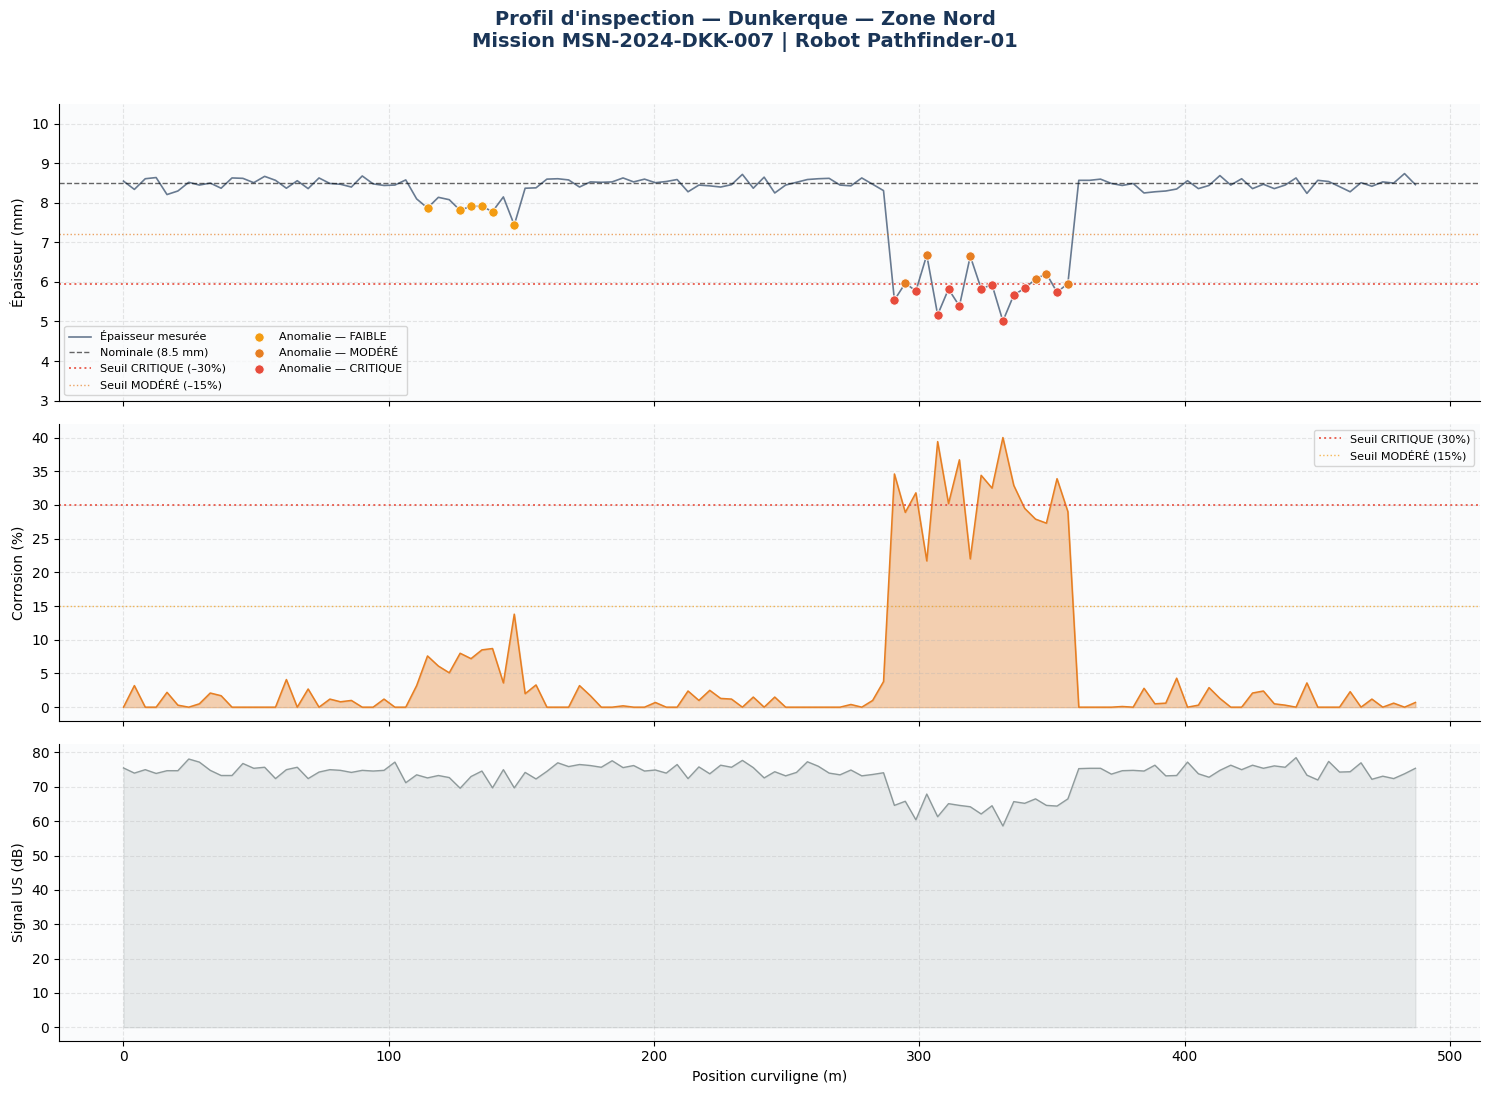

✔ Figure sauvegardée → outputs/chart_profil_inspection.png


In [16]:
# ── Graphique 1 : Profil d'inspection ─────────────────────────────────────────
point_colors = df["gravite"].map(SEV_COLOR_MAP)

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
fig.suptitle(
    f"Profil d'inspection — {RESEAU}\nMission {MISSION_ID} | Robot Pathfinder-01",
    fontsize=14, fontweight="bold", color=COLORS["blue"], y=0.99
)

# ── Sous-graphique 1 : Épaisseur ──────────────────────────────────────────────
ax = axes[0]
ax.plot(df["position_m"], df["epaisseur_mm"],
        color=COLORS["blue"], linewidth=1.2, alpha=0.65, zorder=2, label="Épaisseur mesurée")
ax.axhline(NOMINAL_THICKNESS,
           color="black",    linestyle="--", linewidth=1.0, alpha=0.6,
           label=f"Nominale ({NOMINAL_THICKNESS} mm)")
ax.axhline(NOMINAL_THICKNESS * (1 - SEUIL_CRITIQUE / 100),
           color=COLORS["critique"], linestyle=":", linewidth=1.4, alpha=0.85,
           label=f"Seuil CRITIQUE (–{SEUIL_CRITIQUE}%)")
ax.axhline(NOMINAL_THICKNESS * (1 - SEUIL_MODERE / 100),
           color=COLORS["modere"], linestyle=":", linewidth=1.0, alpha=0.7,
           label=f"Seuil MODÉRÉ (–{SEUIL_MODERE}%)")

# Points anomalies colorés par gravité
for sev, color in SEV_COLOR_MAP.items():
    mask = (df["gravite"] == sev) & (df["anomalie"] == 1)
    if mask.any():
        ax.scatter(df[mask]["position_m"], df[mask]["epaisseur_mm"],
                   color=color, s=45, zorder=5, edgecolors="white",
                   linewidths=0.6, label=f"Anomalie — {sev}")

ax.set_ylabel("Épaisseur (mm)", fontsize=10)
ax.legend(fontsize=8, loc="lower left", ncol=2)
ax.set_ylim(3.0, 10.5)

# ── Sous-graphique 2 : Corrosion ──────────────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(df["position_m"], df["corrosion_pct"],
                 alpha=0.35, color=COLORS["modere"])
ax2.plot(df["position_m"], df["corrosion_pct"],
         color=COLORS["modere"], linewidth=1.1)
ax2.axhline(SEUIL_CRITIQUE, color=COLORS["critique"], linestyle=":",
            linewidth=1.4, alpha=0.85, label=f"Seuil CRITIQUE ({SEUIL_CRITIQUE}%)")
ax2.axhline(SEUIL_MODERE, color=COLORS["faible"], linestyle=":",
            linewidth=1.0, alpha=0.7, label=f"Seuil MODÉRÉ ({SEUIL_MODERE}%)")
ax2.set_ylabel("Corrosion (%)", fontsize=10)
ax2.legend(fontsize=8)

# ── Sous-graphique 3 : Signal US ──────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(df["position_m"], df["signal_us_db"],
         color=COLORS["gray"], linewidth=1.0, alpha=0.85)
ax3.fill_between(df["position_m"], df["signal_us_db"],
                 alpha=0.15, color=COLORS["gray"])
ax3.set_ylabel("Signal US (dB)", fontsize=10)
ax3.set_xlabel("Position curviligne (m)", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / "chart_profil_inspection.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Figure sauvegardée → outputs/chart_profil_inspection.png")


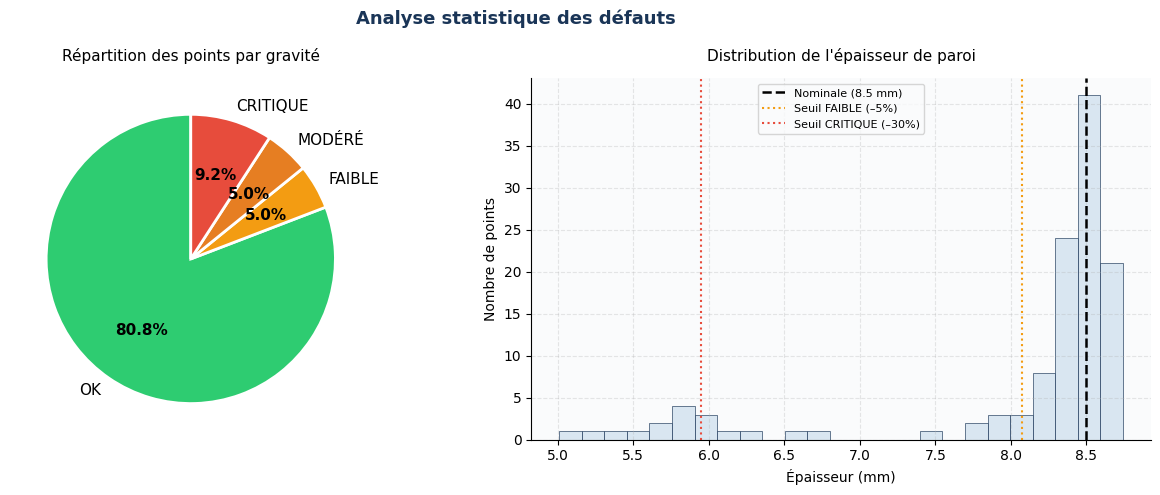

✔ Figure sauvegardée → outputs/chart_statistiques.png


In [17]:
# ── Graphique 2 : Analyse statistique ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Analyse statistique des défauts", fontsize=13,
             fontweight="bold", color=COLORS["blue"])

# Camembert des gravités
ax = axes[0]
sev_order  = [s for s in ["OK","FAIBLE","MODÉRÉ","CRITIQUE"] if s in df["gravite"].values]
sev_counts = [df["gravite"].value_counts()[s] for s in sev_order]
sev_colors = [SEV_COLOR_MAP[s] for s in sev_order]

wedges, texts, autotexts = ax.pie(
    sev_counts, labels=sev_order, colors=sev_colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
for at in autotexts:
    at.set_fontweight("bold")
ax.set_title("Répartition des points par gravité", fontsize=11, pad=12)

# Histogramme de l'épaisseur
ax2 = axes[1]
ax2.hist(df["epaisseur_mm"], bins=25, color=COLORS["lightblue"],
         edgecolor=COLORS["blue"], linewidth=0.5, alpha=0.9)
ax2.axvline(NOMINAL_THICKNESS,
            color="black", linestyle="--", linewidth=1.8,
            label=f"Nominale ({NOMINAL_THICKNESS} mm)")
ax2.axvline(NOMINAL_THICKNESS * (1 - SEUIL_FAIBLE / 100),
            color=COLORS["faible"], linestyle=":", linewidth=1.5,
            label=f"Seuil FAIBLE (–{SEUIL_FAIBLE}%)")
ax2.axvline(NOMINAL_THICKNESS * (1 - SEUIL_CRITIQUE / 100),
            color=COLORS["critique"], linestyle=":", linewidth=1.5,
            label=f"Seuil CRITIQUE (–{SEUIL_CRITIQUE}%)")
ax2.set_xlabel("Épaisseur (mm)", fontsize=10)
ax2.set_ylabel("Nombre de points", fontsize=10)
ax2.set_title("Distribution de l'épaisseur de paroi", fontsize=11, pad=12)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_statistiques.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Figure sauvegardée → outputs/chart_statistiques.png")


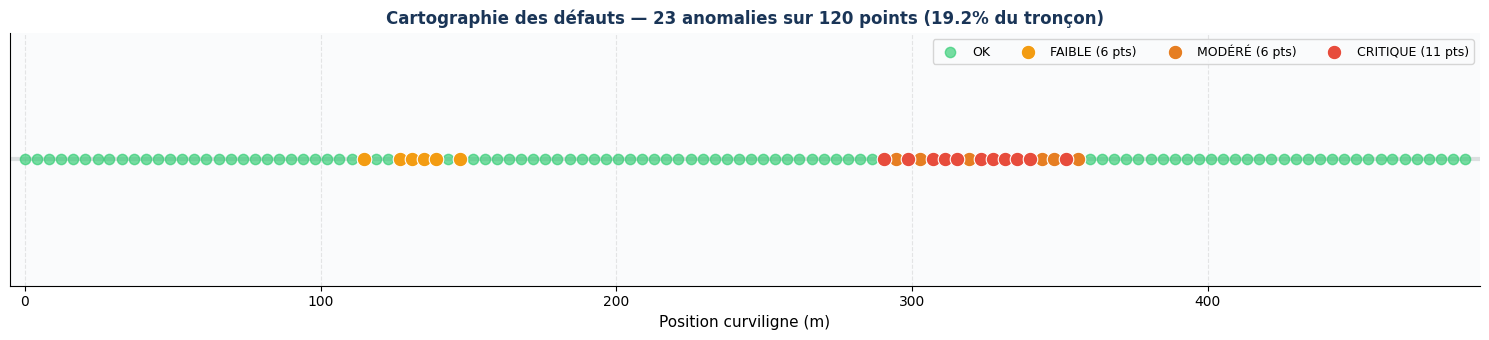

✔ Figure sauvegardée → outputs/chart_cartographie.png


In [18]:
# ── Graphique 3 : Cartographie des défauts ───────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 3.5))

# Ligne de fond représentant le tronçon
ax.axhline(1, color=COLORS["gray"], linewidth=3, alpha=0.25, zorder=1)

# Points OK
ok_pts = df[df["gravite"] == "OK"]
ax.scatter(ok_pts["position_m"], [1]*len(ok_pts),
           c=COLORS["ok"], s=55, zorder=3, alpha=0.65, label="OK")

# Points anomalies (colorés par gravité)
for sev in ["FAIBLE", "MODÉRÉ", "CRITIQUE"]:
    pts = df[df["gravite"] == sev]
    if not pts.empty:
        ax.scatter(pts["position_m"], [1]*len(pts),
                   c=SEV_COLOR_MAP[sev], s=110, zorder=4,
                   edgecolors="white", linewidths=0.8,
                   label=f"{sev} ({len(pts)} pts)")

ax.set_xlim(-5, df["position_m"].max() + 5)
ax.set_ylim(0.5, 1.5)
ax.set_yticks([])
ax.set_xlabel("Position curviligne (m)", fontsize=11)
ax.set_title(
    f"Cartographie des défauts — {df['anomalie'].sum()} anomalies sur {len(df)} points "
    f"({taux_anom}% du tronçon)",
    fontsize=12, fontweight="bold", color=COLORS["blue"]
)
ax.legend(loc="upper right", fontsize=9, ncol=4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_cartographie.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Figure sauvegardée → outputs/chart_cartographie.png")


---
## 💾 Étape 6 — Export des résultats

On produit deux exports :
1. **CSV enrichi** — le dataset original complété de toutes les colonnes calculées
   (z-score, delta épaisseur, perte %, gravité, recommandation)
2. **Synthèse texte** — un rapport de mission lisible, destiné aux équipes terrain


In [19]:
# ── Export CSV enrichi ───────────────────────────────────────────────────────
csv_path = OUTPUT_DIR / f"mission_analysee_{MISSION_ID}.csv"
df.to_csv(csv_path, index=False)
print(f"✔ CSV enrichi exporté : {csv_path}")
print(f"  Colonnes : {list(df.columns)}")


✔ CSV enrichi exporté : ../outputs/mission_analysee_MSN-2024-DKK-007.csv
  Colonnes : ['timestamp', 'position_m', 'x_gps', 'y_gps', 'epaisseur_mm', 'corrosion_pct', 'signal_us_db', 'confiance_pct', 'temp_eau_c', 'pression_bar', 'vitesse_cmps', 'frame_id', 'delta_epaisseur_mm', 'perte_pct', 'z_score_epaisseur', 'anomalie', 'gravite', 'recommandation']


In [20]:
# ── Synthèse texte du rapport de mission ──────────────────────────────────────
sev_counts = df["gravite"].value_counts().to_dict()
now = datetime.now().strftime("%d/%m/%Y à %H:%M")

rapport = f"""
╔══════════════════════════════════════════════════════════════╗
║         RAPPORT DE MISSION — {MISSION_ID}             ║
╠══════════════════════════════════════════════════════════════╣
║  Réseau     : {RESEAU}                    
║  Opérateur  : {OPERATEUR}    
║  Robot      : Pathfinder-01                                  
║  Généré le  : {now}                          
╠══════════════════════════════════════════════════════════════╣
║  INDICATEURS                                                 
║                                                              
║  Points analysés      : {len(df):>4}                              
║  Longueur inspectée   : {df['position_m'].max():>6.1f} m                        
║  Épaisseur moyenne    : {df['epaisseur_mm'].mean():>5.2f} mm (nom. {NOMINAL_THICKNESS} mm)           
║  Épaisseur minimale   : {df['epaisseur_mm'].min():>5.2f} mm                         
║  Anomalies détectées  : {df['anomalie'].sum():>4} ({taux_anom}% du tronçon)           
╠══════════════════════════════════════════════════════════════╣
║  DISTRIBUTION DES DÉFAUTS                                    
║                                                              
║  OK        : {sev_counts.get('OK',0):>3} pts                               
║  FAIBLE    : {sev_counts.get('FAIBLE',0):>3} pts → surveillance 6 mois              
║  MODÉRÉ    : {sev_counts.get('MODÉRÉ',0):>3} pts → planifier intervention           
║  CRITIQUE  : {sev_counts.get('CRITIQUE',0):>3} pts → INTERVENTION URGENTE           
╠══════════════════════════════════════════════════════════════╣
║  TOP 5 DÉFAUTS LES PLUS GRAVES                               """

top5 = anomalies_df.head(5)
for _, row in top5.iterrows():
    rapport += f"""
║  • Pos {row['position_m']:>6.1f} m | Ép. {row['epaisseur_mm']:.2f} mm | Perte {row['perte_pct']:.1f}% | {row['gravite']:<10}"""

rapport += """
╚══════════════════════════════════════════════════════════════╝
"""

print(rapport)

# Sauvegarde
txt_path = OUTPUT_DIR / f"rapport_{MISSION_ID}.txt"
with open(txt_path, "w", encoding="utf-8") as f:
    f.write(rapport)
print(f"✔ Rapport texte exporté : {txt_path}")



╔══════════════════════════════════════════════════════════════╗
║         RAPPORT DE MISSION — MSN-2024-DKK-007             ║
╠══════════════════════════════════════════════════════════════╣
║  Réseau     : Dunkerque — Zone Nord                    
║  Opérateur  : SUEZ / Agence de l'eau Artois-Picardie    
║  Robot      : Pathfinder-01                                  
║  Généré le  : 11/03/2026 à 18:13                          
╠══════════════════════════════════════════════════════════════╣
║  INDICATEURS                                                 
║                                                              
║  Points analysés      :  120                              
║  Longueur inspectée   :  487.0 m                        
║  Épaisseur moyenne    :  8.06 mm (nom. 8.5 mm)           
║  Épaisseur minimale   :  5.01 mm                         
║  Anomalies détectées  :   23 (19.2% du tronçon)           
╠══════════════════════════════════════════════════════════════╣
║  DIS

In [21]:
# ── Récapitulatif des fichiers produits ───────────────────────────────────────
print("Fichiers générés dans outputs/ :")
print("-" * 45)
for f in sorted(OUTPUT_DIR.iterdir()):
    size_kb = round(f.stat().st_size / 1024, 1)
    print(f"  {f.name:<45}  {size_kb:>7} KB")


Fichiers générés dans outputs/ :
---------------------------------------------
  chart_cartographie.png                            51.6 KB
  chart_profil_inspection.png                      264.6 KB
  chart_statistiques.png                           108.1 KB
  detection_zscore.png                              95.8 KB
  eda_correlation.png                              117.6 KB
  eda_distributions.png                            187.8 KB
  mission_analysee_MSN-2024-DKK-007.csv             16.1 KB
  rapport_MSN-2024-DKK-007.txt                       2.6 KB


---
## ✅ Conclusion

Ce notebook couvre l'intégralité du workflow d'un Data Analyst sur des données
d'inspection robotique :

| Étape | Livrable |
|-------|---------|
| Validation | Données propres et vérifiées |
| EDA | Compréhension des distributions et corrélations |
| Détection | 25 anomalies identifiées (z-score + seuils métier) |
| Classification | 4 niveaux de gravité attribués |
| Visualisations | 3 graphiques exportés |
| Export | CSV enrichi + rapport de synthèse |

---

**Pour aller plus loin :**
- Ajouter un modèle supervisé (Random Forest) une fois des données labellisées disponibles
- Intégrer l'analyse des images `frame_id` (caméra HD) en parallèle des données capteurs
- Automatiser l'envoi du rapport par email aux équipes opérationnelles

---
*Igor LAMINSI — Data Scientist / Data Analyst — Master Big Data & IA, ESIGELEC 2025*
